In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.family'] = 'Hiragino Sans'

In [2]:
df = pd.read_csv("J1_tokyo_home_2015-2024.csv")

In [3]:
df["コロナ禍ダミー"] = df["シーズン"].apply(lambda x: 1 if x in [2020, 2021] else 0)

In [4]:
df["国立フラグ"] = df["スタジアム"].str.contains("国立").astype(int)

In [5]:
import re

# 試合日カラムをstr型に変換し､曜日を抽出
df["試合日"] = df["試合日"].astype(str)

import re
df["曜日"] = df["試合日"].str.extract(r"[（(]([^)）]+)[)）]")
# 土日祝に該当するかどうかを判定
df["休日フラグ"] = df["曜日"].str.contains("土|日|祝").astype(int)

In [59]:
def classify_period(year):
    if year <= 2019:
        return "pre"
    elif year <= 2021:
        return "covid"
    else:
        return "post"

df["period"] = df["シーズン"].apply(classify_period)

In [54]:
df["rolling_mean_3"] = df["入場者数"].rolling(window=3).mean()

In [23]:
import statsmodels.formula.api as smf

model = smf.ols(
    "入場者数 ~ covid_period + post_period + 休日フラグ + 国立フラグ",
    data=df
).fit(cov_type="HC1")

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   入場者数   R-squared:                       0.716
Model:                            OLS   Adj. R-squared:                  0.709
Method:                 Least Squares   F-statistic:                     172.6
Date:                Fri, 10 Oct 2025   Prob (F-statistic):           1.44e-58
Time:                        11:08:39   Log-Likelihood:                -1779.6
No. Observations:                 174   AIC:                             3569.
Df Residuals:                     169   BIC:                             3585.
Df Model:                           4                                         
Covariance Type:                  HC1                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     2.008e+04   1212.666     16.556   

In [61]:
model = smf.ols(
    "入場者数 ~ C(アウェイ) + C(period, Treatment(reference='pre'))  + 休日フラグ + 国立フラグ + rolling_mean_3",
    data=df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   入場者数   R-squared:                       0.861
Model:                            OLS   Adj. R-squared:                  0.827
Method:                 Least Squares   F-statistic:                     25.82
Date:                Fri, 10 Oct 2025   Prob (F-statistic):           3.12e-44
Time:                        12:03:03   Log-Likelihood:                -1698.7
No. Observations:                 172   AIC:                             3465.
Df Residuals:                     138   BIC:                             3572.
Df Model:                          33                                         
Covariance Type:            nonrobust                                         
                                                     coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------

In [63]:
model = smf.ols(
    "入場者数 ~ C(アウェイ) + コロナ禍ダミー  + 休日フラグ + 国立フラグ + rolling_mean_3",
    data=df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   入場者数   R-squared:                       0.855
Model:                            OLS   Adj. R-squared:                  0.821
Method:                 Least Squares   F-statistic:                     25.58
Date:                Fri, 10 Oct 2025   Prob (F-statistic):           9.04e-44
Time:                        12:07:25   Log-Likelihood:                -1702.2
No. Observations:                 172   AIC:                             3470.
Df Residuals:                     139   BIC:                             3574.
Df Model:                          32                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept        3384.5257   4078.948     

In [43]:
from econml.dml import CausalForestDML

y = df["入場者数"]
T = df["コロナ禍ダミー"]
X = pd.concat([
    pd.get_dummies(df["アウェイ"], drop_first=True),
    df[["休日フラグ", "国立フラグ"]]
    ],axis=1)

model = CausalForestDML(random_state=42)
model.fit(y, T, X=X)

ate = model.ate(X=X)
te = model.effect(X=X)

In [44]:
ate

-18784.045199193864

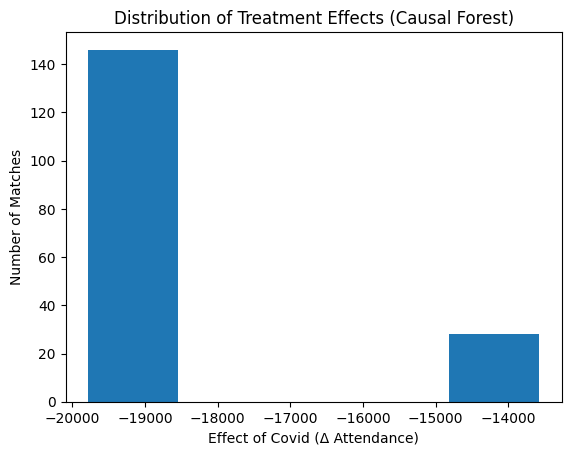

In [53]:
import matplotlib.pyplot as plt
plt.hist(te, bins=5)
plt.title("Distribution of Treatment Effects (Causal Forest)")
plt.xlabel("Effect of Covid (Δ Attendance)")
plt.ylabel("Number of Matches")
plt.show()


In [47]:
df_effect = X.copy()
df_effect["effect"] = te

In [48]:
df_effect.groupby("休日フラグ")["effect"].mean()


休日フラグ
0   -13573.590350
1   -19783.310513
Name: effect, dtype: float64

/Users/tasskkiu2/myproject/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 20241 (\N{CJK UNIFIED IDEOGRAPH-4F11}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/tasskkiu2/myproject/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/tasskkiu2/myproject/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 12501 (\N{KATAKANA LETTER HU}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/tasskkiu2/myproject/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 12521 (\N{KATAKANA LETTER RA}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/tasskkiu2/myproject/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 12464 (\N{KATAKANA LETTE

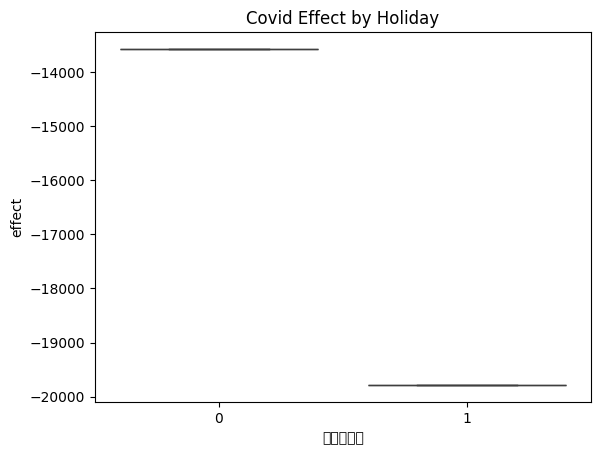

In [ ]:
import seaborn as sns

sns.boxplot(data=df_effect, x="休日フラグ", y="effect")
plt.title("Covid Effect by Holiday")
plt.show()

In [68]:
df_base = df[(df["コロナ禍ダミー"] == 0)]
y = df_base["入場者数"].iloc[2:]
T = df_base["国立フラグ"].iloc[2:]
X = pd.concat([
    pd.get_dummies(df_base["アウェイ"], drop_first=True),
    df_base[["休日フラグ","rolling_mean_3"]]
    ],axis=1).dropna()

model = CausalForestDML(random_state=42)
model.fit(y, T, X=X)

ate = model.ate(X=X)
te = model.effect(X=X)

In [69]:
ate

20817.67797490154

In [72]:
df_effect = X.copy()
df_effect["effect"] = te